# 03. Событийная аналитика и воронка

Как пользователь доходит от просмотра до покупки и где
теряется больше всего.

таблица событий покрывает ноябрь 2019, а таблица заказов заканчивается летом 2018. Это разные источники и разные периоды, сквозной воронки от события до выкупленного заказа построить нельзя. Метрики этого ноутбука не сравниваются с метриками из ноутбуков 01 и 02.

In [43]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import get_engine, query, save_mart
from src import viz

viz.setup()
engine = get_engine()

## 0. Схема таблицы

In [44]:
q = '''
select column_name, data_type
from information_schema.columns
where table_schema = 'sandbox' and table_name = 'events_201911'
order by ordinal_position
'''
pd.read_sql_query(q, engine)

,column_name,data_type
0,event_time,timestamp without time zone
1,event_type,character varying
2,product_id,bigint
3,category_id,bigint
4,price,numeric
5,user_id,bigint
6,user_session,uuid


In [45]:
q = '''
select table_name
from information_schema.tables
where table_schema = 'sandbox'
order by table_name
'''
pd.read_sql_query(q, engine)

,table_name
0,events_201911
1,events_201912
2,order_details
3,orders


## 1. Дневные метрики

In [46]:
ev = query(engine, "events_daily.sql")
ev["dt"] = pd.to_datetime(ev.dt)
ev["cr_dau_to_dac"] = ev.users_purchase / ev.dau * 100
ev["cr_session"] = ev.sessions_purchase / ev.sessions * 100
ev["gmv"] = ev.gmv.astype(float)
ev.head()

,dt,dau,sessions,users_view,users_cart,users_purchase,sessions_purchase,gmv,cr_dau_to_dac,cr_session
0,2019-11-01,14870,25277,14117,3891,913,928,37134.18,6.139879,3.671322
1,2019-11-02,14609,24614,13915,3751,818,826,33607.52,5.599288,3.355814
2,2019-11-03,15525,26337,14845,4045,888,902,36582.87,5.719807,3.424840
3,2019-11-04,16201,26233,15376,4350,945,956,39564.03,5.832973,3.644265
4,2019-11-05,18524,32053,17632,4821,1021,1041,41859.68,5.511769,3.247746


In [47]:
print("период:", ev.dt.min().date(), "-", ev.dt.max().date(), f"({len(ev)} дней)")
print(f"DAU:  среднее {ev.dau.mean():,.0f}, мин {ev.dau.min():,.0f}, макс {ev.dau.max():,.0f}")
print(f"DAC:  среднее {ev.users_purchase.mean():,.0f}")
print(f"конверсия DAU в DAC: медиана {ev.cr_dau_to_dac.median():.1f}%")

период: 2019-11-01 - 2019-11-30 (30 дней)
DAU:  среднее 18,294, мин 14,574, макс 24,265
DAC:  среднее 1,203
конверсия DAU в DAC: медиана 5.9%


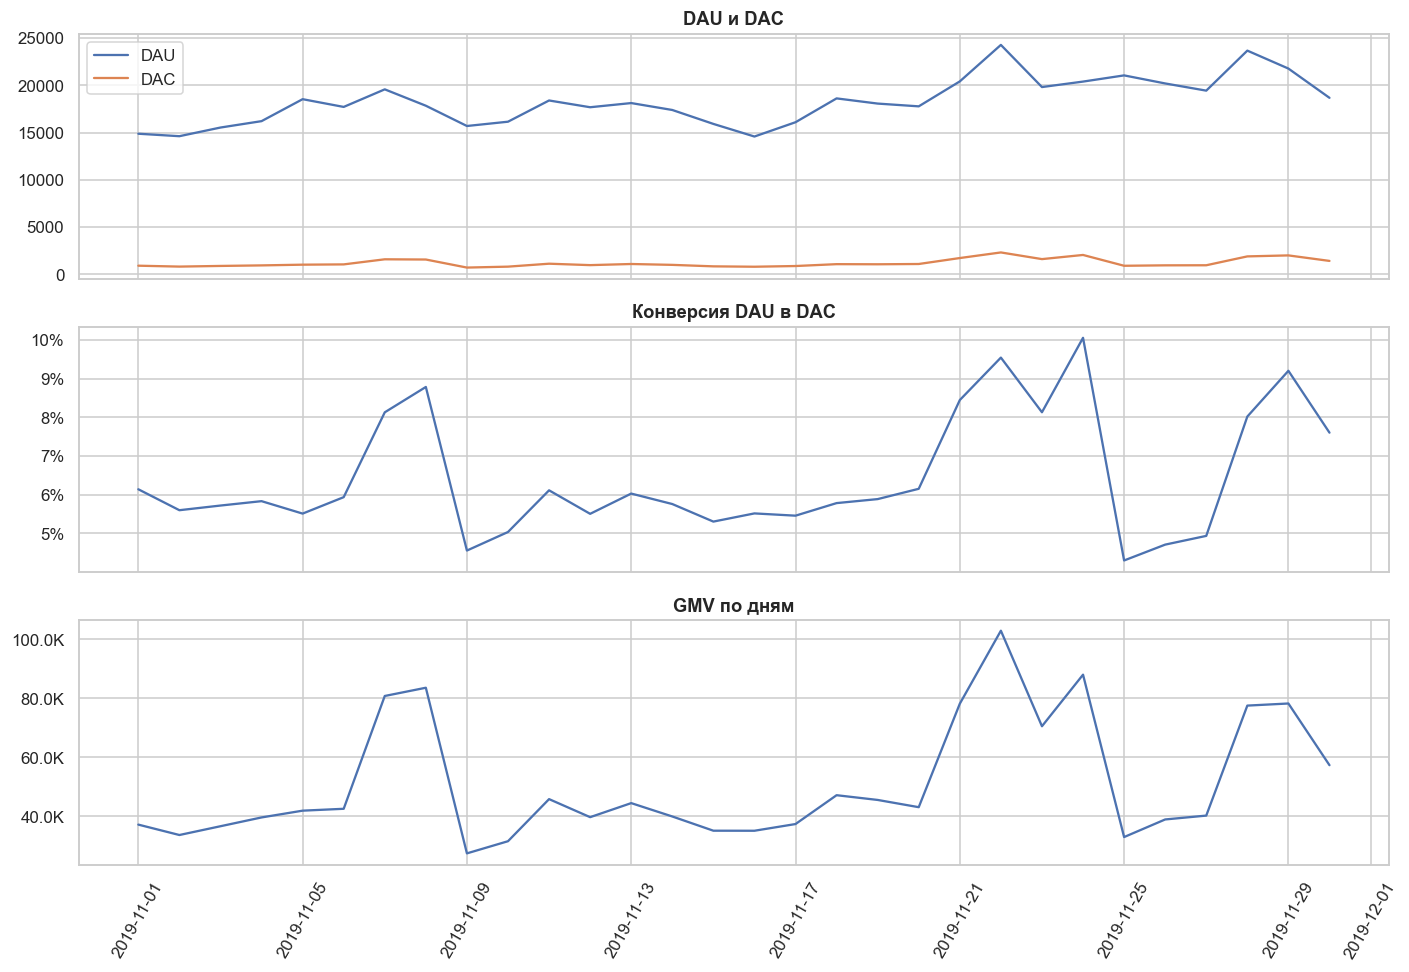

In [48]:
fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

ax[0].plot(ev.dt, ev.dau, label="DAU")
ax[0].plot(ev.dt, ev.users_purchase, label="DAC")
ax[0].legend()
ax[0].set_title("DAU и DAC")

ax[1].plot(ev.dt, ev.cr_dau_to_dac)
ax[1].set_title("Конверсия DAU в DAC")
viz.pct_axis(ax[1])

ax[2].plot(ev.dt, ev.gmv)
ax[2].set_title("GMV по дням")
viz.money_axis(ax[2], unit="K")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## 2. Пик чёрной пятницы

Ноябрь 2019 содержит чёрную пятницу. Если пик есть, средние по месяцу
считать вместе с ним нельзя: несколько аномальных дней сдвинут и DAU, и конверсию,
и все выводы о «нормальном» уровне.


In [49]:
threshold = ev.gmv.median() + 2 * ev.gmv.std()
ev["is_peak"] = ev.gmv > threshold

peak_days = ev.loc[ev.is_peak, ["dt", "dau", "users_purchase", "gmv", "cr_dau_to_dac"]]
print(f"порог GMV: {threshold:,.0f}")
print(f"дней-выбросов: {ev.is_peak.sum()}")
peak_days

порог GMV: 83,257
дней-выбросов: 3


,dt,dau,users_purchase,gmv,cr_dau_to_dac
7,2019-11-08,17832,1566,83522.43,8.781965
21,2019-11-22,24265,2315,102854.76,9.540490
23,2019-11-24,20385,2049,87953.90,10.051508


In [50]:
normal = ev.loc[~ev.is_peak]

comparison = pd.DataFrame({
    "весь месяц": [ev.dau.mean(), ev.users_purchase.mean(),
                   ev.cr_dau_to_dac.mean(), ev.gmv.mean()],
    "без пиковых дней": [normal.dau.mean(), normal.users_purchase.mean(),
                         normal.cr_dau_to_dac.mean(), normal.gmv.mean()],
}, index=["DAU", "DAC", "конверсия DAU в DAC, %", "GMV"]).round(1)

comparison["разница, %"] = (
    (comparison["весь месяц"] / comparison["без пиковых дней"] - 1) * 100
).round(1)
comparison

,весь месяц,без пиковых дней,"разница, %"
DAU,18294.0,18012.6,1.6
DAC,1203.3,1117.3,7.7
"конверсия DAU в DAC, %",6.5,6.1,6.6
GMV,51050.3,46562.1,9.6


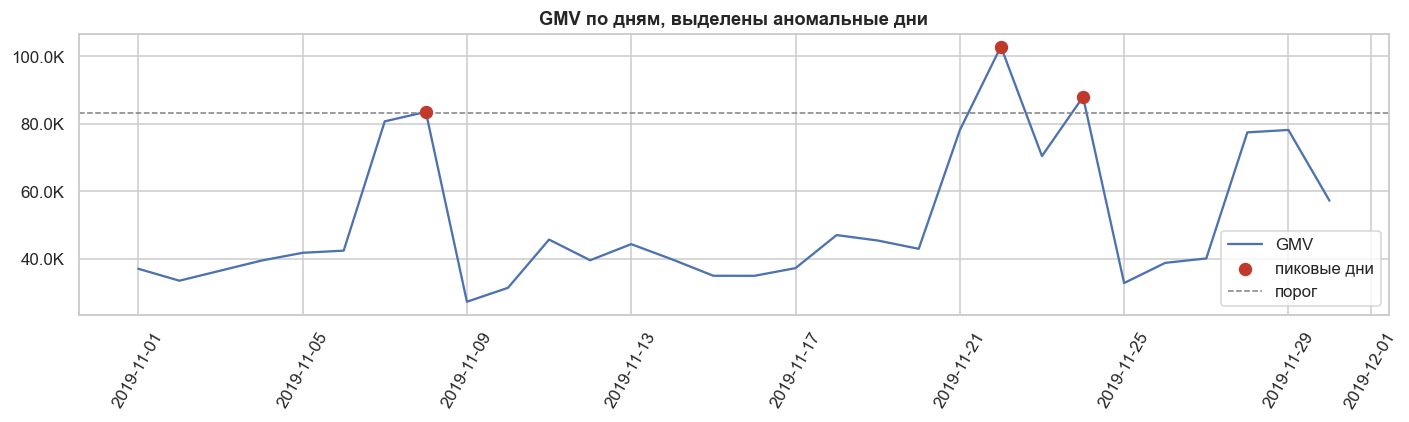

In [51]:
plt.figure(figsize=(13, 4))
plt.plot(ev.dt, ev.gmv, color="#4c72b0", label="GMV")
plt.scatter(ev.loc[ev.is_peak, "dt"], ev.loc[ev.is_peak, "gmv"],
            color="#c0392b", zorder=5, s=60, label="пиковые дни")
plt.axhline(threshold, color="grey", linestyle="--", lw=1, label="порог")
plt.legend()
plt.title("GMV по дням, выделены аномальные дни")
viz.money_axis(unit="K")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

В пик попало 3 дня

## 3. MAU, sticky factor, повторные покупки

In [52]:
q = '''
select
    count(distinct user_id)                                          as mau,
    count(distinct user_id) filter (where event_type = 'purchase')   as buyers
from sandbox.events_201911
'''
mau_row = pd.read_sql_query(q, engine).iloc[0]

mau = int(mau_row.mau)
buyers = int(mau_row.buyers)
avg_dau = ev.dau.mean()

print(f"MAU: {mau:,}")
print(f"покупателей за месяц: {buyers:,}")
print(f"средний DAU: {avg_dau:,.0f}")
print(f"sticky factor DAU/MAU: {avg_dau / mau * 100:.1f}%")
print(f"конверсия MAU в покупателя: {buyers / mau * 100:.1f}%")

MAU: 367,980
покупателей за месяц: 31,524
средний DAU: 18,294
sticky factor DAU/MAU: 5.0%
конверсия MAU в покупателя: 8.6%


In [53]:
q = """
with b as (
    select user_id, count(*) as purchases
    from sandbox.events_201911
    where event_type = 'purchase'
    group by user_id
)
select count(*) as buyers,
       sum(case when purchases > 1 then 1 else 0 end) as repeat_buyers,
       round(avg(purchases), 2) as avg_purchases
from b
"""
rep = pd.read_sql_query(q, engine).iloc[0]
print(f"покупателей: {int(rep.buyers):,}")
print(f"из них с двумя и более покупками: {int(rep.repeat_buyers):,} "
      f"({rep.repeat_buyers / rep.buyers * 100:.1f}%)")
print(f"среднее число покупок на покупателя: {rep.avg_purchases}")

покупателей: 31,524
из них с двумя и более покупками: 28,822 (91.4%)
среднее число покупок на покупателя: 10.23


## 4. Воронка по пользователям за месяц

Первый способ: уникальные пользователи, у которых за месяц было событие каждого типа.
Считаю за весь период, а не максимум по дням: максимум по дням занизил бы верх воронки
в десятки раз, потому что одни и те же пользователи заходят в разные дни.

In [54]:
q = '''
select
    count(distinct user_id) filter (where event_type = 'view')     as users_view,
    count(distinct user_id) filter (where event_type = 'cart')     as users_cart,
    count(distinct user_id) filter (where event_type = 'purchase') as users_purchase
from sandbox.events_201911
'''
totals = pd.read_sql_query(q, engine).iloc[0]

funnel = pd.DataFrame({
    "step": ["view", "cart", "purchase"],
    "users": [totals.users_view, totals.users_cart, totals.users_purchase],
})
funnel["cr_from_prev"] = (funnel.users / funnel.users.shift(1) * 100).round(1)
funnel["cr_from_top"] = (funnel.users / funnel.users.iloc[0] * 100).round(1)
funnel["lost"] = (funnel.users.shift(1) - funnel.users).fillna(0).astype(int)
funnel

,step,users,cr_from_prev,cr_from_top,lost
0,view,355424,NaN,100.0,0
1,cart,95778,26.9,26.9,259646
2,purchase,31524,32.9,8.9,64254


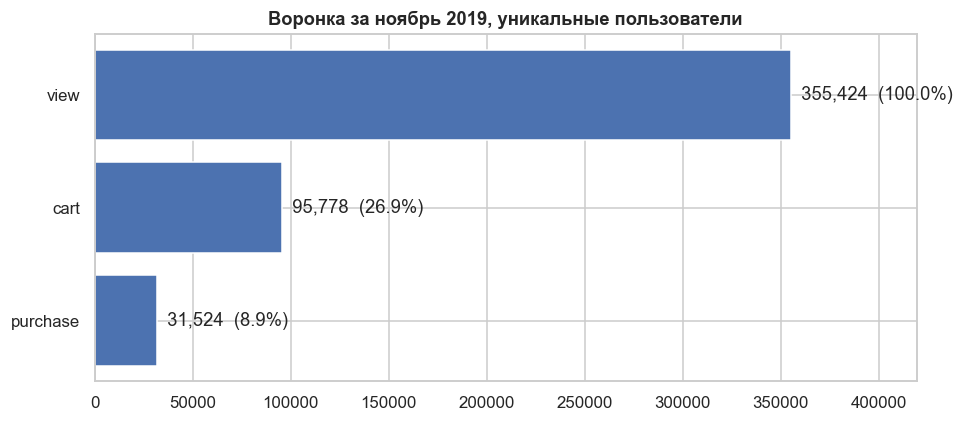

In [55]:
plt.figure(figsize=(9, 4))
bars = plt.barh(funnel.step[::-1], funnel.users[::-1], color="#4c72b0")
for b, v, c in zip(bars, funnel.users[::-1], funnel.cr_from_top[::-1]):
    plt.text(v, b.get_y() + b.get_height() / 2, f"  {v:,.0f}  ({c}%)", va="center")
plt.title("Воронка за ноябрь 2019, уникальные пользователи")
plt.xlim(0, funnel.users.max() * 1.18)
plt.tight_layout()
plt.show()

## 5. Воронка по сессиям

Второй способ: события внутри одной сессии, хотя тоже не гарантирует порядок событий внутри 

In [56]:
q = """
with s as (
    select user_session,
        max(case when event_type = 'view'     then 1 else 0 end) as has_view,
        max(case when event_type = 'cart'     then 1 else 0 end) as has_cart,
        max(case when event_type = 'purchase' then 1 else 0 end) as has_purchase
    from sandbox.events_201911
    group by user_session
)
select count(*) as sessions_total,
       sum(has_view) as with_view,
       sum(case when has_view = 1 and has_cart = 1 then 1 else 0 end) as view_and_cart,
       sum(case when has_view = 1 and has_cart = 1 and has_purchase = 1 then 1 else 0 end) as view_cart_purchase
from s
"""
sess = pd.read_sql_query(q, engine).iloc[0]

funnel_s = pd.DataFrame({
    "step": ["сессия с просмотром", "+ корзина", "+ покупка"],
    "sessions": [int(sess.with_view), int(sess.view_and_cart), int(sess.view_cart_purchase)],
})
funnel_s["cr_from_prev"] = (funnel_s.sessions / funnel_s.sessions.shift(1) * 100).round(1)
funnel_s["cr_from_top"] = (funnel_s.sessions / funnel_s.sessions.iloc[0] * 100).round(1)

print(f"всего сессий: {int(sess.sessions_total):,}")
funnel_s

всего сессий: 937,770


,step,sessions,cr_from_prev,cr_from_top
0,сессия с просмотром,879229,NaN,100.0
1,+ корзина,167846,19.1,19.1
2,+ покупка,25022,14.9,2.8


In [57]:
compare = pd.DataFrame({
    "по пользователям за месяц": funnel.cr_from_top.values,
    "по сессиям": funnel_s.cr_from_top.values,
}, index=["просмотр", "корзина", "покупка"])
compare

,по пользователям за месяц,по сессиям
просмотр,100.0,100.0
корзина,26.9,19.1
покупка,8.9,2.8


## 6. Конверсия по ценовым сегментам

Справочника названий категорий нет, а цена интерпретируется без него.
Ожидание: чем дороже товар, тем ниже конверсия, потому что решение дольше.

In [58]:
q = """
select
    case when price <  20 then '1. до 20'
         when price < 100 then '2. 20-100'
         when price < 500 then '3. 100-500'
         else                  '4. 500+' end as price_bucket,
    count(distinct case when event_type = 'view'     then user_id end) as users_view,
    count(distinct case when event_type = 'cart'     then user_id end) as users_cart,
    count(distinct case when event_type = 'purchase' then user_id end) as users_purchase,
    count(*) filter (where event_type = 'view') as views
from sandbox.events_201911
where price is not null
group by 1
order by 1
"""
fp = pd.read_sql_query(q, engine)

fp["cr_view_to_cart"] = (fp.users_cart / fp.users_view * 100).round(1)
fp["cr_cart_to_purchase"] = (fp.users_purchase / fp.users_cart * 100).round(1)
fp["cr_view_to_purchase"] = (fp.users_purchase / fp.users_view * 100).round(1)
fp["views_share"] = (fp.views / fp.views.sum() * 100).round(1)
fp

,price_bucket,users_view,users_cart,users_purchase,views,cr_view_to_cart,cr_cart_to_purchase,cr_view_to_purchase,views_share
0,1. до 20,303285,91721,30408,1827633,30.2,33.2,10.0,88.4
1,2. 20-100,82195,15175,5132,204609,18.5,33.8,6.2,9.9
2,3. 100-500,17152,1613,369,35487,9.4,22.9,2.2,1.7


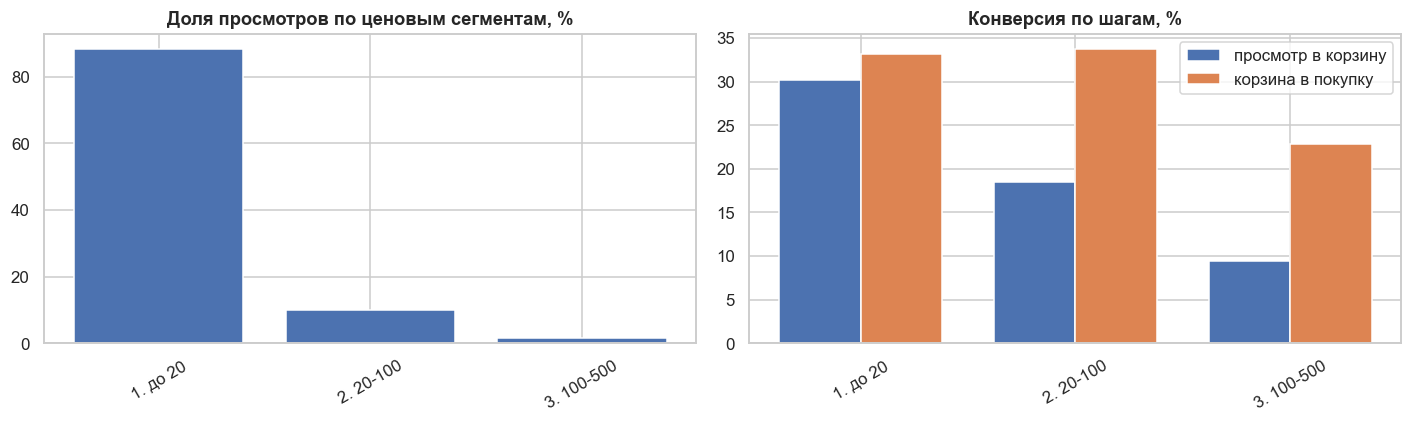

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(fp.price_bucket, fp.views_share, color="#4c72b0")
ax[0].set_title("Доля просмотров по ценовым сегментам, %")
ax[0].tick_params(axis="x", rotation=30)

w = 0.38
x = np.arange(len(fp))
ax[1].bar(x - w / 2, fp.cr_view_to_cart, w, label="просмотр в корзину")
ax[1].bar(x + w / 2, fp.cr_cart_to_purchase, w, label="корзина в покупку")
ax[1].set_xticks(x)
ax[1].set_xticklabels(fp.price_bucket, rotation=30)
ax[1].legend()
ax[1].set_title("Конверсия по шагам, %")

plt.tight_layout()
plt.show()

## 7. Разброс конверсии между категориями

Категории заданы числовым `category_id` без справочника названий. Поэтому
вывод здесь ограниченный: видно, что разброс есть и какого он размера,
но какая именно категория проседает, сказать нельзя.

In [60]:
q = """
select category_id,
    count(distinct case when event_type = 'view'     then user_id end) as users_view,
    count(distinct case when event_type = 'cart'     then user_id end) as users_cart,
    count(distinct case when event_type = 'purchase' then user_id end) as users_purchase
from sandbox.events_201911
where category_id is not null
group by 1
order by users_view desc
limit 15
"""
fc = pd.read_sql_query(q, engine)

fc["category_id"] = fc.category_id.astype(str)
fc["cr_view_to_cart"] = (fc.users_cart / fc.users_view * 100).round(1)
fc["cr_cart_to_purchase"] = (fc.users_purchase / fc.users_cart * 100).round(1)
fc["cr_view_to_purchase"] = (fc.users_purchase / fc.users_view * 100).round(1)
fc.sort_values("cr_view_to_purchase", ascending=False)

,category_id,users_view,users_cart,users_purchase,cr_view_to_cart,cr_cart_to_purchase,cr_view_to_purchase
13,1487580009445982239,8614,7591,3690,88.1,48.6,42.8
7,1487580005268456287,17161,13589,5846,79.2,43.0,34.1
12,1487580008145748965,9002,6441,3032,71.6,47.1,33.7
9,1487580006317032337,13788,10078,4591,73.1,45.6,33.3
6,1487580007675986893,17440,11504,4770,66.0,41.5,27.4
0,1487580005092295511,27268,17467,7038,64.1,40.3,25.8
11,1487580005671109489,10714,8520,2763,79.5,32.4,25.8
8,1487580005595612013,14679,10979,3767,74.8,34.3,25.7
3,1602943681873052386,19939,10406,3757,52.2,36.1,18.8
2,1487580008246412266,21886,7541,2917,34.5,38.7,13.3


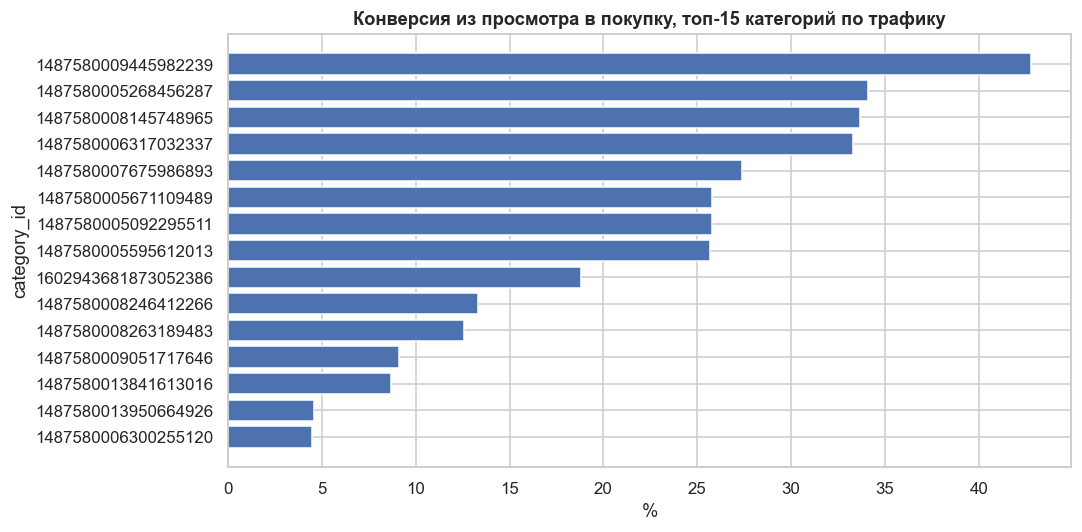

разброс конверсии: от 4.5% до 42.8%, медиана 25.7%, разница в 9.5 раза


In [61]:
plot_df = fc.sort_values("cr_view_to_purchase")
plt.figure(figsize=(10, 5))
plt.barh(plot_df.category_id, plot_df.cr_view_to_purchase, color="#4c72b0")
plt.title("Конверсия из просмотра в покупку, топ-15 категорий по трафику")
plt.xlabel("%")
plt.ylabel("category_id")
plt.tight_layout()
plt.show()

spread = fc.cr_view_to_purchase
print(f"разброс конверсии: от {spread.min()}% до {spread.max()}%, "
      f"медиана {spread.median()}%, разница в {spread.max() / spread.min():.1f} раза")

## 8. Сохраняем витрины

In [62]:
save_mart(ev, "events_daily")
save_mart(funnel, "events_funnel")
save_mart(funnel_s, "events_funnel_sessions")
save_mart(fp, "events_funnel_by_price")
save_mart(fc, "events_funnel_by_category")

сохранено: data/marts/events_daily.csv, строк 30
сохранено: data/marts/events_funnel.csv, строк 3
сохранено: data/marts/events_funnel_sessions.csv, строк 3
сохранено: data/marts/events_funnel_by_price.csv, строк 3
сохранено: data/marts/events_funnel_by_category.csv, строк 15


PosixPath('/Users/m1/Desktop/marketplace-analytics/data/marts/events_funnel_by_category.csv')

## Выводы

1. Основная потеря в воронке  между просмотром и корзиной.
До корзины доходят 26.9% пользователей, теряются 259 646 человек. Дальше потери втрое меньше: из корзины в покупку переходят 32.9%. 

2. Три аномальных дня сдвигают средние, но это не чёрная пятница.
Выбросы пришлись на 8, 22 и 24 ноября, а чёрная пятница 2019 это 29-е, и всплеска в этот день нет. Пики завышают средний GMV на 9.6% и DAC на 7.7% при почти неизменном DAU (+1.6%), то есть в эти дни активнее покупали те же пользователи, а не новые. 

3. Конверсия падает с ростом цены в 4.5 раза, и решение принимается до корзины.
Из просмотра в покупку: 10.0% в сегменте до 20, 6.2% в 20–100, 2.2% в 100–500. 

4. Воронка по пользователям за месяц завышает конверсию в 3.2 раза.
По пользователям 8.9% доходят до покупки, по сессиям 2.8%. Разница в том, что первый способ склеивает просмотр в начале месяца с покупкой в конце.